# Reporte 00: Construcción del Grafo Topológico (Modelo VFT)

## 1. Justificación Teórica: Del GeoJSON al Grafo Matemático

En el análisis de redes de transporte urbano, un mapa estático (polígonos y líneas) es insuficiente para modelar el comportamiento operativo. El **Modelo Vanishing Fig-Tree (VFT)** requiere transformar las geometrías espaciales extraídas de la APIMETRO (en formato GeoJSON) en una estructura matemática conocida como **Grafo Dirigido**.

Matemáticamente, definimos la red topológica como:
$$G = (V, E)$$

Donde:
* **$V$ (Vértices o Nodos):** Representan las estaciones del sistema. Sus atributos incluyen las coordenadas espaciales estáticas (longitud, latitud) y su jerarquía operativa (ej. "masivo_pesado", "superficie_convencional").
* **$E$ (Aristas o Edges):** Representan los vectores de flujo continuo entre dos vértices adyacentes ($\vec{uv}$). Cada arista posee atributos dinámicos cruciales, principalmente la **Impedancia Temporal**, la cual está condicionada por el coeficiente de fricción vial, el derecho de vía y la velocidad comercial del sistema.

Esta transformación espacial nos permite aplicar algoritmos de enrutamiento y evaluar la resiliencia y accesibilidad del sistema anillar de la Ciudad de México.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from IPython.display import display, Markdown

# Silenciamos advertencias de visualización
warnings.filterwarnings('ignore')

proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

from src.infrastructure.go_client.client import fetch_full_network
from src.api.schemas.schemas import GeoJSONTransportSchema
from src.core.services.graph_builder import build_and_plot_network
from src.core.utils.visualizer import plot_vft_graph

print("1. Conectando con APIMETRO (Go) para ingestar la red espacial...")
raw_data = await fetch_full_network()

print("2. Validando contrato de datos espaciales (Pydantic)...")
validated_payload = GeoJSONTransportSchema(**raw_data)
print(f"✅ Ingesta exitosa: Se validaron {len(validated_payload.features)} features espaciales.")

1. Conectando con APIMETRO (Go) para ingestar la red espacial...
2026-04-07 20:02:42 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-04-07 20:02:42 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-04-07 20:02:42 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-04-07 20:02:42 | INFO     | VFT_Model | Red extraída: 22785 entidades espaciales listas para VFT.
2. Validando contrato de datos espaciales (Pydantic)...
✅ Ingesta exitosa: Se validaron 22785 features espaciales.


## 2. Renderizado del Grafo VFT: Construcción Paso a Paso

Para comprender cómo el **Modelo VFT** procesa la geometría espacial y la transforma en una estructura matemática operativa, a continuación se desglosa la construcción de la red topológica en cuatro etapas analíticas.

2026-04-07 20:06:43 | INFO     | VFT_Model | Iniciando la construcción del Grafo VFT...
2026-04-07 20:06:43 | INFO     | VFT_Model | Grafo Dirigido construido: 101621 Nodos topológicos y 93816 Segmentos de flujo.
2026-04-07 20:06:43 | INFO     | VFT_Model | Llamando al Motor de Impedancia VFT...
2026-04-07 20:06:43 | INFO     | VFT_Model | Iniciando inyección de motor de impendancia sobre VFT:
2026-04-07 20:06:44 | INFO     | VFT_Model | Impedancia aplicada exitosamente a 93816 segmentos.
✅ Grafo topológico construido exitosamente: 101621 nodos y 93816 aristas.



---

### Etapa 1: Vértices Topológicos y Jerarquía del Sistema ($V$)

El primer paso consiste en mapear estrictamente las estaciones como vértices. El tamaño y color de cada nodo representan su **jerarquía de transporte** (Masivo Pesado, Mediano o Superficie Convencional). Esta es la base esquelética donde interactúan los transbordos.

2026-04-07 20:06:44 | INFO     | VFT_Model | Visualizador inicializado. Pre-procesando geometrías...
2026-04-07 20:06:44 | INFO     | VFT_Model | Renderizando paneles solicitados: All=1
2026-04-07 20:06:45 | INFO     | VFT_Model | Visualización guardada exitosamente en: ASSETS/00_Panel1_Nodos_Jerarquia.png


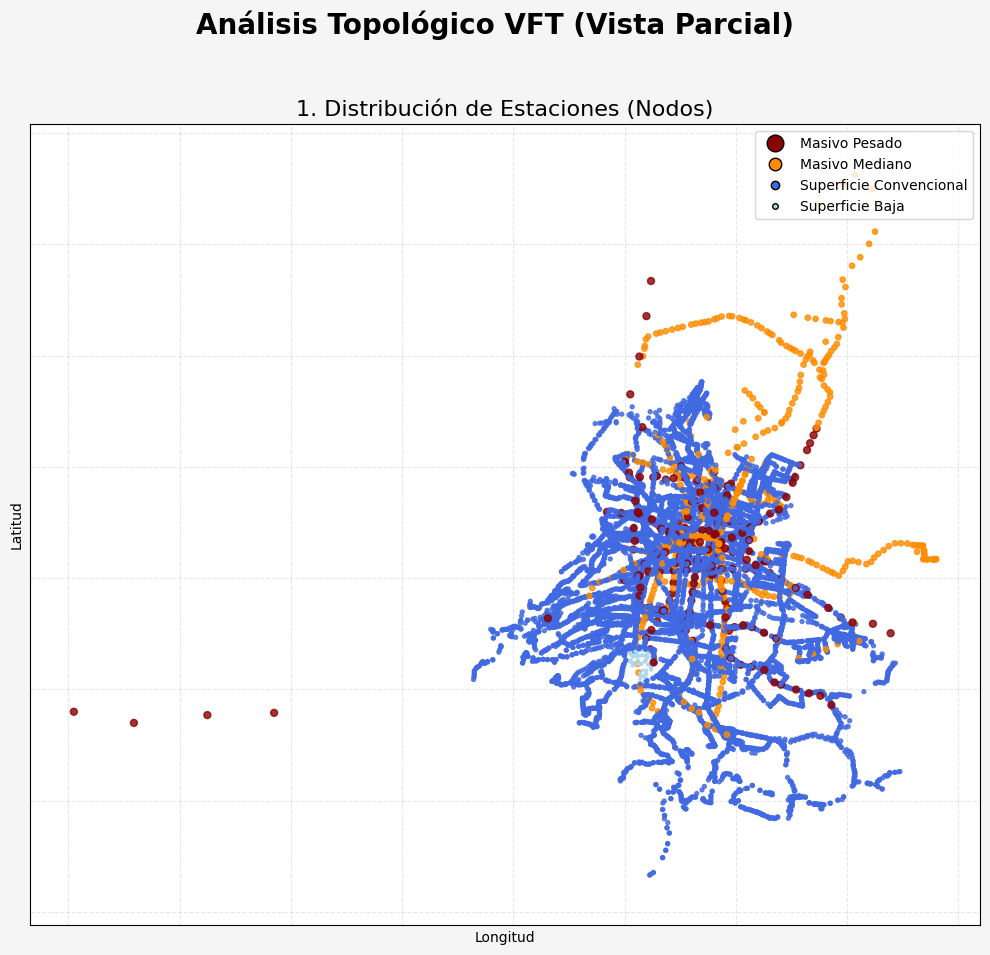

---

### Etapa 2: Arcos y Topología Espacial ($E$)

A continuación, se trazan los segmentos de conexión física. La red pasa de ser un conjunto aislado de puntos a un **grafo continuo**. El grosor y color de los arcos mapean características vitales como el derecho de vía y la velocidad comercial.

2026-04-07 20:06:45 | INFO     | VFT_Model | Visualizador inicializado. Pre-procesando geometrías...
2026-04-07 20:06:45 | INFO     | VFT_Model | Renderizando paneles solicitados: All=2
2026-04-07 20:06:46 | INFO     | VFT_Model | Visualización guardada exitosamente en: ASSETS/00_Panel2_Arcos_Espaciales.png


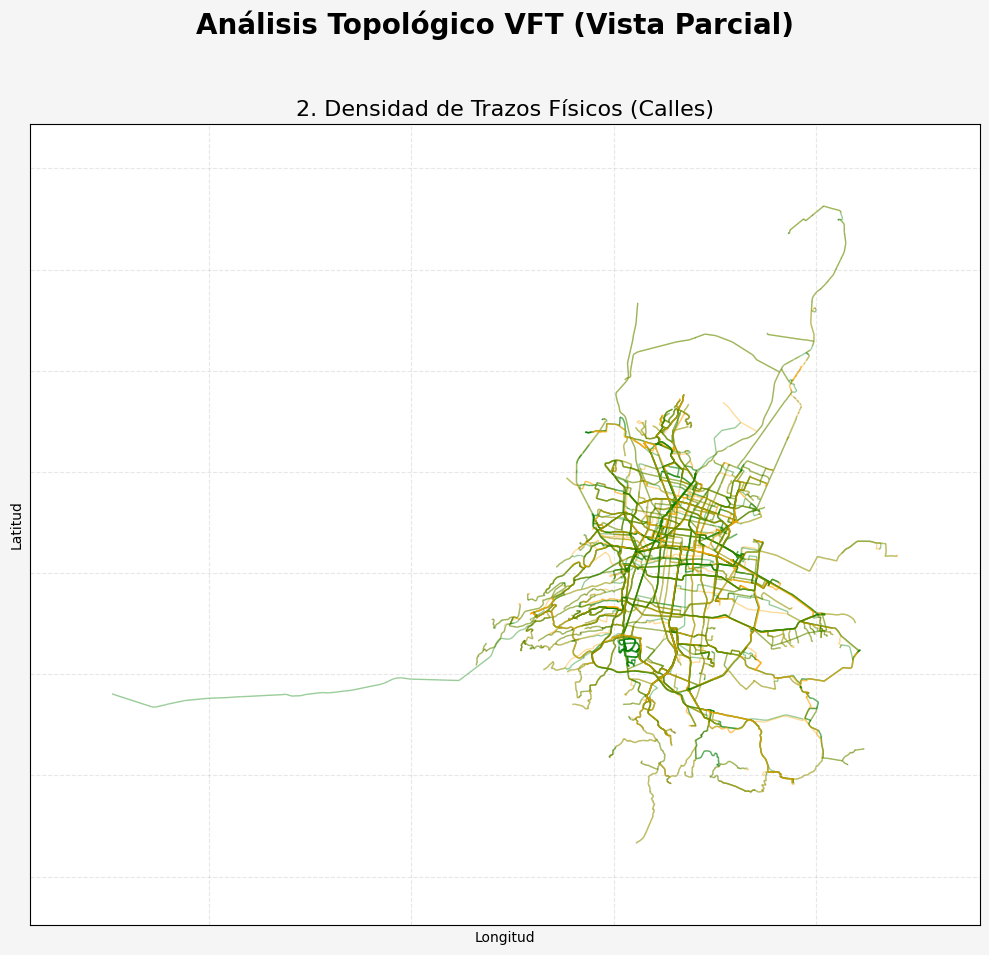

---

### Etapa 3: Direccionalidad Operativa (Flujos de Ida)

Al ser un Grafo Dirigido (DiGraph), la red no es simétrica. Aquí visualizamos los vectores de flujo continuo en su sentido de operación principal (Ida). Esta asimetría es crucial para que el Motor de Impedancia calcule el verdadero costo de viaje temporal.

2026-04-07 20:06:46 | INFO     | VFT_Model | Visualizador inicializado. Pre-procesando geometrías...
2026-04-07 20:06:46 | INFO     | VFT_Model | Renderizando paneles solicitados: All=3
2026-04-07 20:07:27 | INFO     | VFT_Model | Visualización guardada exitosamente en: ASSETS/00_Panel3_Flujos_Ida.png


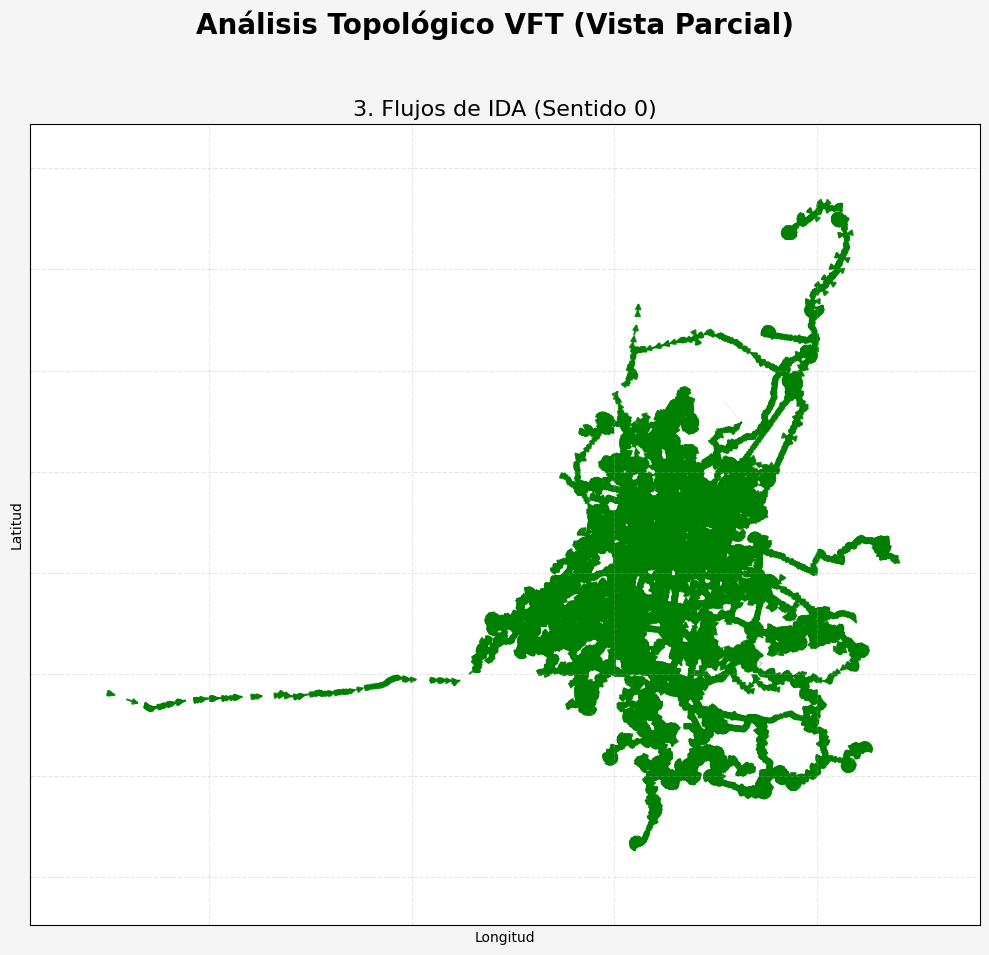

---

### Etapa 4: Direccionalidad Operativa (Flujos de Regreso)

Finalmente, se mapean las aristas en sentido inverso. Al contrastarse con el flujo de ida, el modelo es capaz de identificar discrepancias viales, cuellos de botella y evaluar la resiliencia bidireccional del sistema completo.

2026-04-07 20:07:38 | INFO     | VFT_Model | Visualizador inicializado. Pre-procesando geometrías...
2026-04-07 20:07:38 | INFO     | VFT_Model | Renderizando paneles solicitados: All=4
2026-04-07 20:08:19 | INFO     | VFT_Model | Visualización guardada exitosamente en: ASSETS/00_Panel4_Flujos_Regreso.png


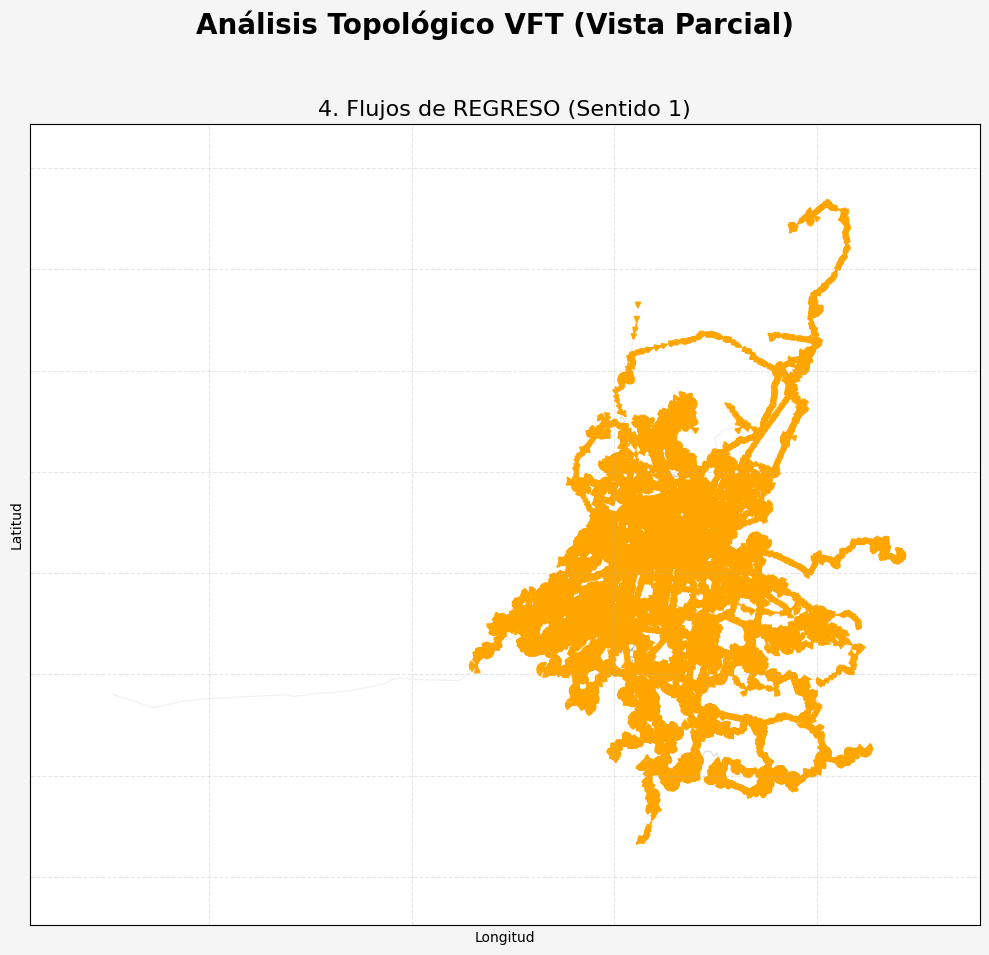

In [4]:
import networkx as nx
from IPython.display import display, Markdown

display(Markdown("## 2. Renderizado del Grafo VFT: Construcción Paso a Paso"))
display(Markdown("Para comprender cómo el **Modelo VFT** procesa la geometría espacial y la transforma en una estructura matemática operativa, a continuación se desglosa la construcción de la red topológica en cuatro etapas analíticas."))

# 1. Construir el Grafo Dirigido con atributos e impedancia
G = build_and_plot_network(validated_payload)

if isinstance(G, nx.DiGraph):
    print(f"✅ Grafo topológico construido exitosamente: {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.\n")
    
    # ---------------------------------------------------------
    # PANEL 1: Nodos y Jerarquía
    # ---------------------------------------------------------
    display(Markdown("---"))
    display(Markdown("### Etapa 1: Vértices Topológicos y Jerarquía del Sistema ($V$)"))
    display(Markdown("El primer paso consiste en mapear estrictamente las estaciones como vértices. El tamaño y color de cada nodo representan su **jerarquía de transporte** (Masivo Pesado, Mediano o Superficie Convencional). Esta es la base esquelética donde interactúan los transbordos."))
    plot_vft_graph(G, All=1, save_name="00_Panel1_Nodos_Jerarquia")
    
    # ---------------------------------------------------------
    # PANEL 2: Aristas y Topología
    # ---------------------------------------------------------
    display(Markdown("---"))
    display(Markdown("### Etapa 2: Arcos y Topología Espacial ($E$)"))
    display(Markdown("A continuación, se trazan los segmentos de conexión física. La red pasa de ser un conjunto aislado de puntos a un **grafo continuo**. El grosor y color de los arcos mapean características vitales como el derecho de vía y la velocidad comercial."))
    plot_vft_graph(G, All=2, save_name="00_Panel2_Arcos_Espaciales")

    # ---------------------------------------------------------
    # PANEL 3: Flujos de Ida
    # ---------------------------------------------------------
    display(Markdown("---"))
    display(Markdown("### Etapa 3: Direccionalidad Operativa (Flujos de Ida)"))
    display(Markdown("Al ser un Grafo Dirigido (DiGraph), la red no es simétrica. Aquí visualizamos los vectores de flujo continuo en su sentido de operación principal (Ida). Esta asimetría es crucial para que el Motor de Impedancia calcule el verdadero costo de viaje temporal."))
    plot_vft_graph(G, All=3, save_name="00_Panel3_Flujos_Ida")

    # ---------------------------------------------------------
    # PANEL 4: Flujos de Regreso
    # ---------------------------------------------------------
    display(Markdown("---"))
    display(Markdown("### Etapa 4: Direccionalidad Operativa (Flujos de Regreso)"))
    display(Markdown("Finalmente, se mapean las aristas en sentido inverso. Al contrastarse con el flujo de ida, el modelo es capaz de identificar discrepancias viales, cuellos de botella y evaluar la resiliencia bidireccional del sistema completo."))
    plot_vft_graph(G, All=4, save_name="00_Panel4_Flujos_Regreso")

else:
    print("⚠️ Error: La función 'build_and_plot_network' no devolvió un objeto DiGraph. Verifica el archivo graph_builder.py.")